# Capítulo 18: La ecuación de difusión

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jfbonder/imc/blob/main/notebooks/09-calor.ipynb)

Notebook que acompaña al Capítulo 18 (La ecuación de difusión) de *Introducción al Modelado Continuo*. Sigue el orden del texto: el **paseo al azar** cuyo límite continuo es la ecuación del calor $\partial_t u = D\,\partial_{xx}u$; la **barra en dimensión 1** resuelta por separación de variables (el régimen transitorio $V$, la solución $u$ y su convergencia al estado estacionario en un tiempo del orden de $L^2/D$); la **solución fundamental** $\Phi(x,t)$ en la recta; el ejemplo en el **cuadrado** $[0,1]^2$ con fuente $f=1$, cuya convergencia al equilibrio tiene la tasa $D\lambda_1$ que predice la desigualdad de Poincaré con la mejor constante; y, al final, el **problema conductor de la temperatura del suelo**: los datos reales de un año, la solución periódica $u_{per} = \bar T + A e^{-x/\delta}\cos(\omega t - x/\delta)$ y la estimación de la difusividad $D$ a partir de la atenuación y el retraso de los ciclos anual y diario.

En cada caso verificamos numéricamente lo que el texto afirma: que el esquema de diferencias finitas (`imc.numerico.calor_explicito`, estable si $r = D\,\Delta t/\Delta x^2 \le 1/2$) reproduce la serie de Fourier, que $\int\Phi\,dx = 1$ y la masa se conserva, que la energía $\int v^2$ del régimen transitorio decrece, y que la tasa de decaimiento ajustada en el cuadrado coincide con $D\lambda_1 = 2\pi^2 D$.

In [1]:
# Configuración (funciona en Colab y en una copia local del repositorio)
try:
    import imc
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/jfbonder/imc.git"], check=True)
    import imc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from imc import estilo, numerico, datos
from imc.estilo import COLORES, CICLO

estilo.activar(fuente=14)   # las figuras de un panel van a 0.5-0.6\textwidth (~8-9 cm): fuente grande para que se lean impresas
GUARDAR = False   # True para regenerar las figuras de las notas en figuras/


def fuente(F):
    '''Contexto con fuente F en ejes y ticks (leyenda F-2) para las figuras de varios paneles (van a 0.9-0.95\textwidth).'''
    return plt.rc_context({"font.size": F, "axes.labelsize": F, "axes.titlesize": F, "xtick.labelsize": F - 1,
                           "ytick.labelsize": F - 1, "legend.fontsize": F - 2, "lines.linewidth": 2.0})


def norma_L2(v, h):
    '''Norma L^2 de una función dada en una grilla uniforme de paso h (en 1 o 2 dimensiones).'''
    return np.sqrt(h ** v.ndim * np.sum(v ** 2))

## 18.2 Movimiento browniano y paseo al azar

**Figura `Browniano`**: una realización de una partícula browniana en el plano. La simulamos como un paseo al azar con pasos gaussianos: en cada intervalo $\Delta t$ la partícula se desplaza $(\Delta X, \Delta Y)$ con $\Delta X, \Delta Y \sim \mathcal N(0, 2D\,\Delta t)$ independientes, de modo que $\mathrm{Var}[X(t)] = 2Dt$, que es la relación de Einstein $D = \sigma^2(\tau)/(2\tau)$ del texto. Marcamos el inicio y el fin de la trayectoria.

D = 0.5, dt = 0.001, 5000 pasos: t final = 5; distancia final al origen 2.04, sqrt(4 D t) = 3.16


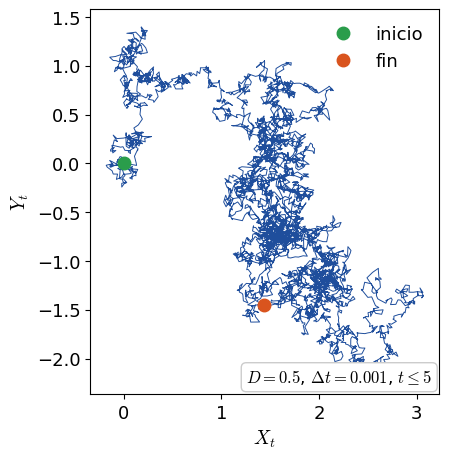

In [2]:
rng = np.random.default_rng(3)
D_b, dt_b, N_b = 0.5, 1e-3, 5000
pasos = np.sqrt(2 * D_b * dt_b) * rng.normal(size=(N_b, 2))
XY = np.vstack([[0, 0], np.cumsum(pasos, axis=0)])
print(f"D = {D_b}, dt = {dt_b}, {N_b} pasos: t final = {N_b * dt_b:g}; distancia final al origen {np.hypot(*XY[-1]):.2f}, sqrt(4 D t) = {np.sqrt(4 * D_b * N_b * dt_b):.2f}")

fig, ax = plt.subplots(figsize=(5.2, 5))
ax.plot(XY[:, 0], XY[:, 1], color=COLORES["traj"], lw=0.7)
ax.plot(0, 0, "o", color=COLORES["nul_p"], ms=9, label="inicio", zorder=5)
ax.plot(*XY[-1], "o", color=COLORES["modelo"], ms=9, label="fin", zorder=5)
ax.set_xlabel("$X_t$"); ax.set_ylabel("$Y_t$"); ax.set_aspect("equal"); ax.legend(loc="upper right")
estilo.parametros(ax, f"$D = {D_b}$, $\\Delta t = {dt_b}$, $t \\leq {N_b * dt_b:g}$", loc="lower right", fontsize=12)
if GUARDAR: estilo.guardar(fig, "Browniano")

**El paseo al azar y su límite continuo.** Con la notación de la Sección 18.2: la partícula está en $x_j = j\,\Delta x$ y en cada paso $\Delta t$ salta $\pm\Delta x$ con probabilidad $1/2$, así que $p_j^{n+1} = \tfrac12 p_{j-1}^n + \tfrac12 p_{j+1}^n$. Tras $n$ pasos la posición es una suma de $n$ variables $\pm\Delta x$: tiene media $0$ y varianza $n\,\Delta x^2 = 2D\,t_n$ con $D = \Delta x^2/(2\Delta t)$, y el teorema central del límite dice que su distribución se parece a la gaussiana de esa varianza, que es exactamente la solución fundamental $\Phi(x, t_n)$ de la ecuación del calor. *Figura nueva `paseo-azar`* (iría junto a la Figura `Browniano`): (a) unas trayectorias del paseo, con la envolvente $\pm\sqrt{2Dt}$; (b) el histograma de la posición de $20\,000$ partículas tras $n = 100$ pasos, la probabilidad exacta $p_j^n$ calculada con la recurrencia (dividida por $2\Delta x$, porque tras $n$ pasos sólo se ocupan los sitios con $j \equiv n \pmod 2$) y la gaussiana $\Phi(x, t_n)$.

tras n = 100 pasos: media 0.028, varianza 97.90 (teoría n dx^2 = 2 D t_n = 100)
suma de p_j^n = 1.000000 (conservación de la probabilidad); varianza exacta 100.00
max |p_j^n / (2 dx) - Phi(x_j, t_n)| en los sitios ocupados: 1.0e-04  (máximo de Phi: 0.0399)


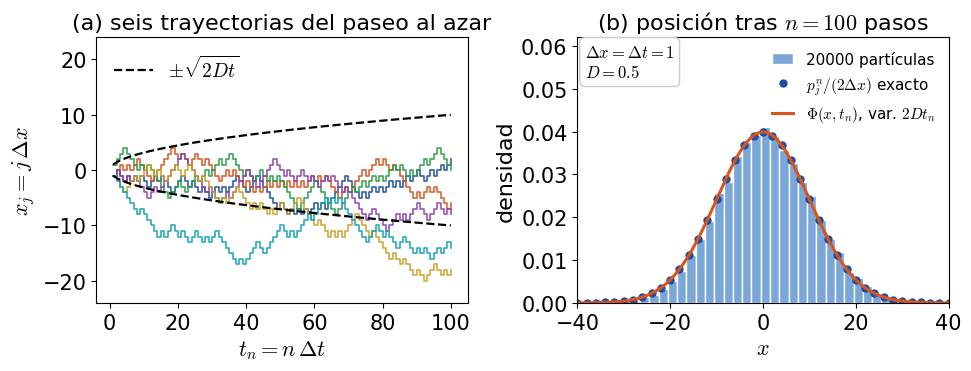

In [3]:
dx, dt = 1.0, 1.0                      # unidades del paseo: Delta x = Delta t = 1, D = 1/2
D_pa = dx ** 2 / (2 * dt)
n_pasos, M = 100, 20000
saltos = rng.choice([-dx, dx], size=(M, n_pasos))
X = np.cumsum(saltos, axis=1)                                       # M trayectorias
t_n = dt * np.arange(1, n_pasos + 1)
print(f"tras n = {n_pasos} pasos: media {X[:, -1].mean():.3f}, varianza {X[:, -1].var():.2f} (teoría n dx^2 = 2 D t_n = {2 * D_pa * t_n[-1]:.0f})")

# recurrencia exacta p_j^{n+1} = (p_{j-1}^n + p_{j+1}^n)/2, partiendo de p_0^0 = 1
p = np.zeros(2 * n_pasos + 1); p[n_pasos] = 1.0
for _ in range(n_pasos):
    p = 0.5 * (np.roll(p, 1) + np.roll(p, -1))
j = np.arange(-n_pasos, n_pasos + 1)
print(f"suma de p_j^n = {p.sum():.6f} (conservación de la probabilidad); varianza exacta {np.sum(p * (j * dx) ** 2):.2f}")
Phi = lambda x, t, D: np.exp(-x ** 2 / (4 * D * t)) / np.sqrt(4 * np.pi * D * t)   # solución fundamental
ocupados = (j + n_pasos) % 2 == 0
print(f"max |p_j^n / (2 dx) - Phi(x_j, t_n)| en los sitios ocupados: {np.abs(p[ocupados] / (2 * dx) - Phi(j[ocupados] * dx, t_n[-1], D_pa)).max():.1e}  (máximo de Phi: {Phi(0, t_n[-1], D_pa):.4f})")

with fuente(16):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    for k in range(6):
        ax1.step(t_n, X[k], where="post", lw=1.2, color=CICLO[k % 6], alpha=0.9)
    ax1.plot(t_n, np.sqrt(2 * D_pa * t_n), "k--", lw=1.6, label=r"$\pm\sqrt{2Dt}$"); ax1.plot(t_n, -np.sqrt(2 * D_pa * t_n), "k--", lw=1.6)
    ax1.set_xlabel("$t_n = n\\,\\Delta t$"); ax1.set_ylabel("$x_j = j\\,\\Delta x$"); ax1.set_ylim(-24, 24); ax1.set_title("(a) seis trayectorias del paseo al azar"); ax1.legend(loc="upper left")
    ax2.hist(X[:, -1], bins=np.arange(-40.5, 41.5, 2), density=True, color=COLORES["traj2"], edgecolor="white", label=f"{M} partículas")
    ax2.plot(j[ocupados] * dx, p[ocupados] / (2 * dx), "o", color=COLORES["traj"], ms=5, label="$p_j^n / (2\\Delta x)$ exacto")
    xx = np.linspace(-40, 40, 400)
    ax2.plot(xx, Phi(xx, t_n[-1], D_pa), color=COLORES["modelo"], lw=2.2, label=r"$\Phi(x, t_n)$, var. $2Dt_n$")
    ax2.set_xlim(-40, 40); ax2.set_ylim(0, 0.062); ax2.set_xlabel("$x$"); ax2.set_ylabel("densidad"); ax2.set_title(f"(b) posición tras $n = {n_pasos}$ pasos"); ax2.legend(loc="upper right", fontsize=11, handlelength=1.4)
    estilo.parametros(ax2, f"$\\Delta x = \\Delta t = 1$\n$D = {D_pa}$", loc="upper left", fontsize=12)
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, "paseo-azar")

## 18.3 La ecuación del calor en dimensión 1

El problema del texto: la barra $[0, L]$ inicialmente a temperatura $u_0$, con el extremo izquierdo fijo en $u_0$ y el derecho en $u_L > u_0$. En las variables adimensionales $y = x/L$, $s = t/\tau$ con $\tau = L^2/D$, el régimen transitorio $V = y - v$ resuelve la ecuación del calor con borde nulo y dato inicial $V(y,0) = y$, y por separación de variables
$$V(y,s) = \sum_{k\ge1}\frac{2(-1)^{k+1}}{k\pi}\,e^{-k^2\pi^2 s}\sin(k\pi y).$$
**Figura `V-heat`**: $V$ para $s = 0.001, 0.01, 0.05, 0.2, 0.5$ y el dato inicial. La serie se suma con `V_serie` (para $s>0$ los términos decaen como $e^{-k^2\pi^2 s}$: con $400$ términos el resto es despreciable ya para $s = 0.001$). Fijate cómo la discontinuidad del dato en $y = 1$ ($V(1,0^+) = 1$ pero $V(1,s) = 0$) se suaviza instantáneamente, y cómo la solución se va pareciendo al primer modo $\frac2\pi e^{-\pi^2 s}\sin(\pi y)$ (a $s = 0.05$, línea de puntos, todavía se nota el segundo modo, que decae como $e^{-4\pi^2 s}$; para $s \gtrsim 0.2$ son indistinguibles).

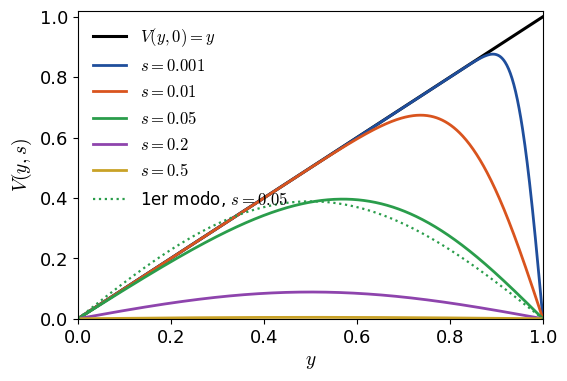

In [4]:
def V_serie(y, s, K=400):
    '''Régimen transitorio V(y, s) = sum_k 2(-1)^(k+1)/(k pi) e^(-k^2 pi^2 s) sin(k pi y), K términos.'''
    k = np.arange(1, K + 1)[:, None]
    return np.sum(2 * (-1.0) ** (k + 1) / (k * np.pi) * np.exp(-k ** 2 * np.pi ** 2 * s) * np.sin(k * np.pi * np.asarray(y)[None, :]), axis=0)

y = np.linspace(0, 1, 801)
tiempos_s = [0.001, 0.01, 0.05, 0.2, 0.5]
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(y, y, color="black", lw=2.2, label="$V(y,0) = y$")
for s, c in zip(tiempos_s, CICLO):
    ax.plot(y, V_serie(y, s), color=c, lw=2, label=f"$s = {s}$")
ax.plot(y, 2 / np.pi * np.exp(-np.pi ** 2 * 0.05) * np.sin(np.pi * y), ":", color=CICLO[2], lw=1.6, label="1er modo, $s = 0.05$")
ax.set_xlabel("$y$"); ax.set_ylabel("$V(y, s)$"); ax.set_xlim(0, 1); ax.set_ylim(0, 1.02); ax.legend(loc="upper left", fontsize=12)
if GUARDAR: estilo.guardar(fig, "V-heat")

**Figura `u-heat`**: en las variables originales, $u(x,t) = u_0 + (u_L - u_0)\bigl[x/L - V(x/L, Dt/L^2)\bigr]$, con $L = 4$, $D = 0.1$, $u_0 = 1$, $u_L = 3$ como en el texto ($\tau = L^2/D = 160$). Elegimos los tiempos $t = 0.5, 2, 5, 20, 50$ y $160$ para que se vea toda la evolución hasta el tiempo característico, donde la solución es indistinguible del estado estacionario $u^*(x) = u_0 + (u_L - u_0)x/L$ (a trazos): el primer modo vale $\frac2\pi e^{-\pi^2}\simeq 3\times10^{-5}$. (La figura original del texto tenía curvas a $t = 0.05, \dots, 10$ ya casi estacionarias, que corresponden a $D \simeq 0.4$ y no al $D = 0.1$ del caption; ver el informe.)

L = 4.0, D = 0.1: tau = L^2/D = 160.  Amplitud del primer modo, (2/pi) e^(-pi^2 D t / L^2):
   t =   0.5 (s = 0.0031): 6.17e-01;   max |u(x,t) - u*(x)| = 1.60e+00
   t =     2 (s = 0.0125): 5.63e-01;   max |u(x,t) - u*(x)| = 1.29e+00
   t =     5 (s = 0.0312): 4.68e-01;   max |u(x,t) - u*(x)| = 9.83e-01
   t =    20 (s = 0.1250): 1.85e-01;   max |u(x,t) - u*(x)| = 3.71e-01
   t =    50 (s = 0.3125): 2.91e-02;   max |u(x,t) - u*(x)| = 5.83e-02
   t =   160 (s = 1.0000): 3.29e-05;   max |u(x,t) - u*(x)| = 6.59e-05


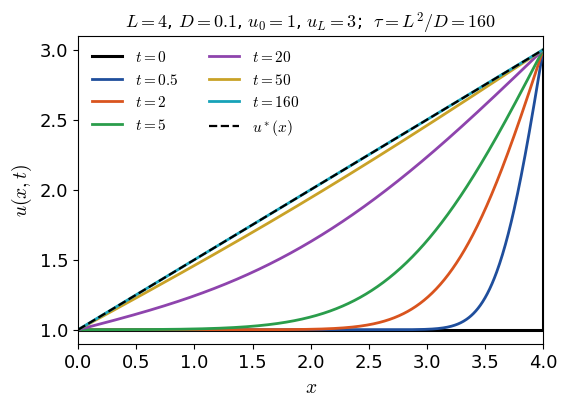

In [5]:
L, D1, u_0, u_L = 4.0, 0.1, 1.0, 3.0
tau = L ** 2 / D1
x = np.linspace(0, L, 801)
u_exacta = lambda x, t: u_0 + (u_L - u_0) * (x / L - V_serie(x / L, D1 * t / L ** 2))
u_est = u_0 + (u_L - u_0) * x / L
tiempos_t = [0.5, 2, 5, 20, 50, 160]
print(f"L = {L}, D = {D1}: tau = L^2/D = {tau:g}.  Amplitud del primer modo, (2/pi) e^(-pi^2 D t / L^2):")
for t in tiempos_t:
    print(f"   t = {t:5g} (s = {t / tau:.4f}): {2 / np.pi * np.exp(-np.pi ** 2 * t / tau):.2e};   max |u(x,t) - u*(x)| = {(u_L - u_0) * np.abs(V_serie(x / L, t / tau)).max():.2e}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([0, L, L], [u_0, u_0, u_L], color="black", lw=2.2, label="$t = 0$")
for t, c in zip(tiempos_t, CICLO):
    ax.plot(x, u_exacta(x, t), color=c, lw=2, label=f"$t = {t:g}$")
ax.plot(x, u_est, "--", color="black", lw=1.6, label="$u^*(x)$", zorder=5)
ax.set_xlabel("$x$"); ax.set_ylabel("$u(x, t)$"); ax.set_xlim(0, L); ax.set_ylim(0.9, 3.1); ax.legend(loc="upper left", fontsize=11, ncol=2)
ax.set_title(f"$L = {L:g}$, $D = {D1}$, $u_0 = {u_0:g}$, $u_L = {u_L:g}$;  $\\tau = L^2/D = {tau:g}$", fontsize=13)
if GUARDAR: estilo.guardar(fig, "u-heat")

**Verificaciones.** (i) El esquema explícito de diferencias finitas `numerico.calor_explicito` (con $r = D\,\Delta t/\Delta x^2 = 0.4 \le 1/2$) partiendo del dato constante $u_0$ y con los bordes fijos en $(u_0, u_L)$ reproduce la serie. (ii) La energía $e(s) = \int_0^1 V^2\,dy$ del régimen transitorio decrece (es la cuenta de la unicidad: $e' = -2\int V_y^2 \le 0$), y su tasa de decaimiento $-\frac{d}{ds}\ln\|V\|_2$ tiende a $\lambda_1 = \pi^2$ (el primer autovalor de $-d^2/dy^2$ en $(0,1)$ con Dirichlet): en las variables originales, $\pi^2 D/L^2$.

In [6]:
dx1 = L / 200; dt1 = 0.4 * dx1 ** 2 / D1
xg = np.arange(0, L + dx1 / 2, dx1)
u_num = numerico.calor_explicito(np.full(xg.size, u_0), D1, dx1, dt1, int(round(20 / dt1)), borde=(u_0, u_L))
print(f"esquema explícito: dx = {dx1}, dt = {dt1:.2e}, r = {D1 * dt1 / dx1 ** 2:.2f}, {u_num.shape[0] - 1} pasos hasta t = 20")
for t in [0.5, 2, 5, 20]:
    n = int(round(t / dt1))
    print(f"   t = {t:4g}: max |u_num - u_serie| = {np.abs(u_num[n] - u_exacta(xg, n * dt1)).max():.1e}")

ss = np.array([0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5])
e = np.array([np.trapezoid(V_serie(y, s) ** 2, y) for s in ss])
print(f"\ne(s) = int V^2 dy en s = {ss.tolist()}:\n   {np.array2string(e, precision=4)}  (decreciente: {np.all(np.diff(e) < 0)}; e(0) = 1/3)")
tasa = -np.diff(np.log(np.sqrt(e))) / np.diff(ss)
print(f"tasa -d/ds ln||V||_2 en cada tramo: {np.array2string(tasa, precision=2)}  ->  pi^2 = {np.pi ** 2:.2f}; en variables originales pi^2 D/L^2 = {np.pi ** 2 * D1 / L ** 2:.4f}")

esquema explícito: dx = 0.02, dt = 1.60e-03, r = 0.40, 12500 pasos hasta t = 20
   t =  0.5: max |u_num - u_serie| = 8.6e-04
   t =    2: max |u_num - u_serie| = 2.1e-04
   t =    5: max |u_num - u_serie| = 8.6e-05
   t =   20: max |u_num - u_serie| = 1.6e-05

e(s) = int V^2 dy en s = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5]:
   [2.8487e-01 2.3050e-01 1.9376e-01 1.4766e-01 7.6507e-02 2.8168e-02
 3.9103e-03 5.4318e-04 1.0481e-05]  (decreciente: True; e(0) = 1/3)
tasa -d/ds ln||V||_2 en cada tramo: [26.48 17.36 13.59 10.96  9.99  9.87  9.87  9.87]  ->  pi^2 = 9.87; en variables originales pi^2 D/L^2 = 0.0617


## 18.4 La ecuación del calor en la recta

En $\mathbb R$ la solución es la convolución del dato con la solución fundamental $\Phi(x,t) = (4\pi Dt)^{-1/2}e^{-x^2/(4Dt)}$, la densidad normal de varianza $2Dt$ (la misma gaussiana del paseo al azar). **Figura `sol-fundamental`**: $\Phi$ para $t = 0.05, 0.1, 0.5, 1, 4$ con $D = 0.4$ (los valores de la figura original). Verificamos que $\int\Phi\,dx = 1$ y que la varianza es $2Dt$, y la **conservación de la masa**: para $g = \mathbf 1_{[-1,1]}$, $\int (g*\Phi)(x,t)\,dx = \int g = 2$ para todo $t$, mientras que $\max_x u(\cdot,t)$ decae como $t^{-1/2}$ (a diferencia del intervalo con Dirichlet, donde $\|u\|_2$ decae exponencialmente: en la recta no hay $\lambda_1 > 0$).

masa del dato: int g dx = 2.0050 (suma en la grilla)
    t   int Phi  varianza    2Dt   int u   max u  max u * sqrt(t)
 0.05  1.000000    0.0400   0.04  2.0050  1.0000           0.2236
  0.1  1.000000    0.0800   0.08  2.0050  0.9996           0.3161
  0.5  1.000000    0.4000   0.40  2.0050  0.8871           0.6272
    1  1.000000    0.8000   0.80  2.0050  0.7376           0.7376
    4  1.000000    3.2000   3.20  2.0050  0.4248           0.8496


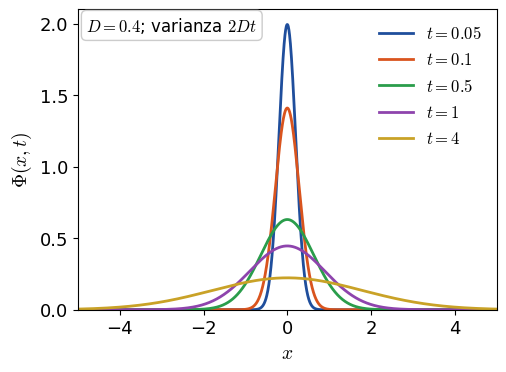

In [7]:
D_R = 0.4
xr = np.linspace(-12, 12, 4801); dxr = xr[1] - xr[0]
tiempos_R = [0.05, 0.1, 0.5, 1.0, 4.0]
g = (np.abs(xr) <= 1).astype(float)
print(f"masa del dato: int g dx = {g.sum() * dxr:.4f} (suma en la grilla)")
print(f"{'t':>5s} {'int Phi':>9s} {'varianza':>9s} {'2Dt':>6s} {'int u':>7s} {'max u':>7s} {'max u * sqrt(t)':>16s}")
for t in tiempos_R:
    Ph = Phi(xr, t, D_R)
    u_t = np.convolve(g, Ph, mode="same") * dxr                       # (g * Phi)(x, t)
    print(f"{t:5g} {np.trapezoid(Ph, xr):9.6f} {np.trapezoid(xr ** 2 * Ph, xr):9.4f} {2 * D_R * t:6.2f} {u_t.sum() * dxr:7.4f} {u_t.max():7.4f} {u_t.max() * np.sqrt(t):16.4f}")

fig, ax = plt.subplots(figsize=(5.4, 3.9))
for t, c in zip(tiempos_R, CICLO):
    ax.plot(xr, Phi(xr, t, D_R), color=c, lw=2, label=f"$t = {t:g}$")
ax.set_xlim(-5, 5); ax.set_ylim(0, 2.1); ax.set_xlabel("$x$"); ax.set_ylabel(r"$\Phi(x, t)$"); ax.legend(loc="upper right", fontsize=12)
estilo.parametros(ax, f"$D = {D_R}$; varianza $2Dt$", loc="upper left", fontsize=12)
if GUARDAR: estilo.guardar(fig, "sol-fundamental")

## 18.5 Dimensión $n > 1$: el cuadrado con fuente

El ejemplo del texto: $\Omega = [0,1]^2$, $u_t - D\Delta u = f$ con $f \equiv 1$, $u = 0$ en $\partial\Omega$, dato inicial $g = 0$ y $D = 0.4$. Lo resolvemos con el esquema explícito de cinco puntos `numerico.calor_explicito_2d` (estable si $r = D\,\Delta t/h^2 \le 1/4$; usamos $h = 1/40$, $r = 0.2$) y calculamos el estado estacionario $u^*$, solución de $-D\Delta u^* = 1$, resolviendo el sistema lineal del mismo Laplaciano discreto (`scipy.sparse`). Como control, $u^*$ tiene la serie doble de senos $u^*(x,y) = \sum_{k,l\ \mathrm{impares}}\frac{16}{\pi^2 kl}\,\frac{\sin(k\pi x)\sin(l\pi y)}{D\pi^2(k^2 + l^2)}$, cuyo máximo (en el centro) es $0.07367/D \simeq 0.184$.

In [8]:
D2, h2 = 0.4, 1 / 40
m2 = int(round(1 / h2)) - 1                                            # nodos interiores por lado
xg2 = np.linspace(0, 1, m2 + 2); X2, Y2 = np.meshgrid(xg2, xg2)
A1 = sp.csr_matrix(numerico.matriz_laplaciano_1d(m2, h2)); I1 = sp.identity(m2)
Lap = sp.kron(I1, A1) + sp.kron(A1, I1)                                # Laplaciano de cinco puntos (Dirichlet), ordenado por filas
u_est2 = np.zeros((m2 + 2, m2 + 2))
u_est2[1:-1, 1:-1] = spla.spsolve((-D2 * Lap).tocsc(), np.ones(m2 * m2)).reshape(m2, m2)

def u_est_serie(x, y, D, K=99):
    k = np.arange(1, K + 1, 2)[:, None, None]; l = np.arange(1, K + 1, 2)[None, :, None]
    return np.sum(16 / (np.pi ** 2 * k * l) * np.sin(k * np.pi * x) * np.sin(l * np.pi * y) / (D * np.pi ** 2 * (k ** 2 + l ** 2)), axis=(0, 1))
print(f"u* discreto: máximo {u_est2.max():.5f} en el centro; serie de senos: {float(u_est_serie(np.array([0.5]), np.array([0.5]), D2)[0]):.5f}; diferencia máxima en la grilla {np.abs(u_est2 - u_est_serie(X2.ravel(), Y2.ravel(), D2).reshape(X2.shape)).max():.1e}")

dt2 = 0.2 * h2 ** 2 / D2
cada = 5
t2, U2 = numerico.calor_explicito_2d(np.zeros_like(u_est2), D2, h2, dt2, int(round(0.5 / dt2)), f=1.0, cada=cada)
err2 = np.array([norma_L2(U - u_est2, h2) for U in U2])
print(f"esquema explícito 2D: h = {h2:g}, dt = {dt2:.2e}, r = {D2 * dt2 / h2 ** 2:.2f}, {int(round(0.5 / dt2))} pasos hasta t = 0.5 (guardado cada {cada})")
print(f"||u(0) - u*||_2 = ||u*||_2 = {err2[0]:.4f};  en t = 0.5: {err2[-1]:.2e}  (cota e^(-2 pi^2 D t) ||u*|| = {err2[0] * np.exp(-2 * np.pi ** 2 * D2 * 0.5):.2e})")

u* discreto: máximo 0.18409 en el centro; serie de senos: 0.18418; diferencia máxima en la grilla 9.0e-05
esquema explícito 2D: h = 0.025, dt = 3.13e-04, r = 0.20, 1600 pasos hasta t = 0.5 (guardado cada 5)
||u(0) - u*||_2 = ||u*||_2 = 0.1031;  en t = 0.5: 1.97e-03  (cota e^(-2 pi^2 D t) ||u*|| = 1.99e-03)


*Figura nueva `heat2d`* (reemplaza a `estacionaria-heat` y a `heat2d-1..4`, que eran superficies 3D con distinta escala cada una): la solución $u(x,y,t)$ en $t = 0, 0.05, 0.1, 0.2, 0.5$ y el estado estacionario $u^*$, con la misma escala de color en todos los paneles. A $t = 0.5$ la diferencia con $u^*$ es de $2\times10^{-3}$ en norma $L^2$ (el $2\%$ del valor inicial), invisible en la figura.

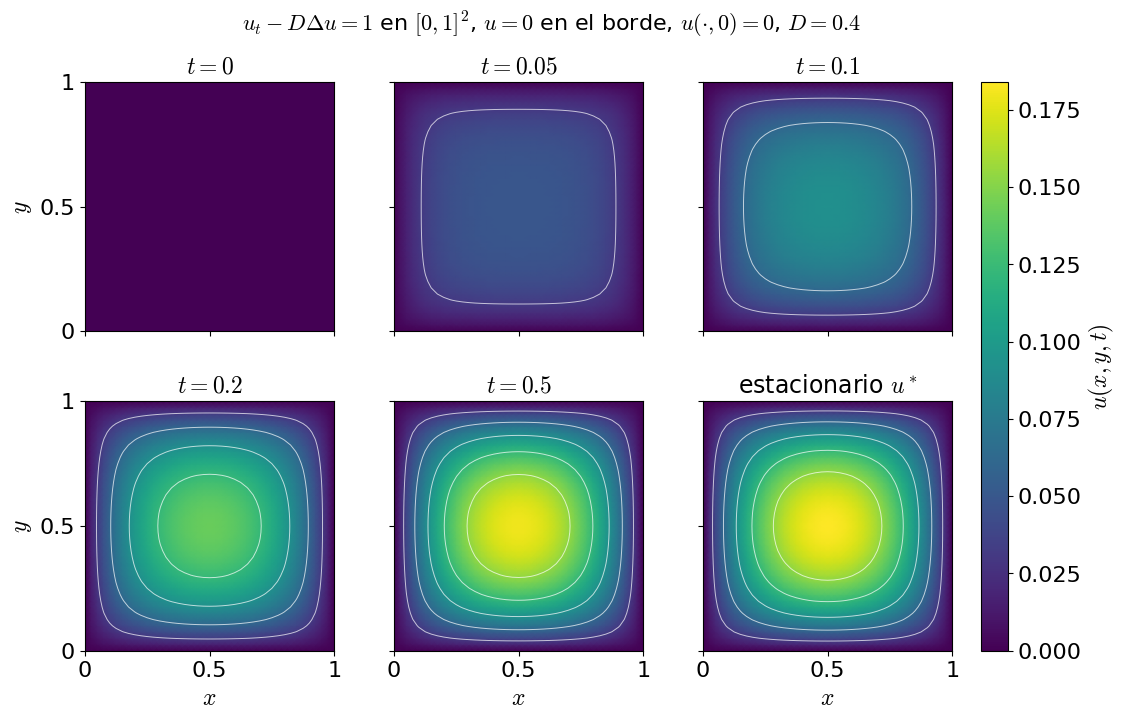

In [9]:
instantes = [0.0, 0.05, 0.1, 0.2, 0.5]
with fuente(17):
    fig, axs = plt.subplots(2, 3, figsize=(11, 7.2), sharex=True, sharey=True)
    vmax = u_est2.max()
    for ax, t in zip(axs.ravel(), instantes + [None]):
        U = u_est2 if t is None else U2[np.argmin(np.abs(t2 - t))]
        im = ax.pcolormesh(xg2, xg2, U, cmap="viridis", vmin=0, vmax=vmax, shading="gouraud", rasterized=True)
        ax.contour(xg2, xg2, U, levels=np.linspace(0, vmax, 7)[1:-1], colors="white", linewidths=0.7, alpha=0.7)
        ax.set_title("estacionario $u^*$" if t is None else f"$t = {t:g}$"); ax.set_aspect("equal"); ax.set_xticks([0, 0.5, 1], ["0", "0.5", "1"]); ax.set_yticks([0, 0.5, 1], ["0", "0.5", "1"])
    for ax in axs[1]: ax.set_xlabel("$x$")
    for ax in axs[:, 0]: ax.set_ylabel("$y$")
    fig.subplots_adjust(left=0.07, right=0.87, top=0.87, bottom=0.08, wspace=0.18, hspace=0.28)
    cb = fig.colorbar(im, cax=fig.add_axes([0.89, 0.08, 0.025, 0.79])); cb.set_label("$u(x, y, t)$")
    fig.suptitle(r"$u_t - D\Delta u = 1$ en $[0,1]^2$, $u = 0$ en el borde, $u(\cdot, 0) = 0$, $D = 0.4$", fontsize=16, y=0.97)
    if GUARDAR: estilo.guardar(fig, "heat2d")

**Figura `errores-heat-log`**: $\|u(\cdot,t) - u^*\|_2$ en escala logarítmica, con la recta ajustada por mínimos cuadrados en $t\in[0.05, 0.5]$. La teoría (desigualdad de Poincaré con la mejor constante, Observación 18.x) dice que la tasa es $D\lambda_1$ con $\lambda_1 = 2\pi^2$ en el cuadrado unitario, es decir $0.8\pi^2 \simeq 7.90$, mientras que la cota general $\pi^2/d^2$ con $d = \sqrt2$ sólo garantiza $1.97$. El ajuste da $7.90$. El texto reporta una pendiente de $7.6$ y la atribuye al error de discretización y al transitorio inicial; en realidad es la huella del esquema *implícito* con $\Delta t = 0.01$ con que se hizo la figura original: cada paso multiplica el primer modo por $(1 + D\lambda_1\Delta t)^{-1}$, así que la tasa observada es $\ln(1 + D\lambda_1\Delta t)/\Delta t = 7.60$. Lo comprobamos corriendo ese esquema.

tasa ajustada (t en [0.05, 0.5]): 7.9015;  D lambda_1 = 0.8 pi^2 = 7.8957;  cota del diámetro pi^2 D / d^2 = 1.9739
lambda_1 estimado = tasa / D = 19.754  (2 pi^2 = 19.739; el Laplaciano discreto con h = 1/40 tiene lambda_1,h = 19.729)
esquema implícito con dt = 0.01: tasa ajustada 7.598;  ln(1 + D lambda_1 dt)/dt = 7.599  (el 7.6 del texto)


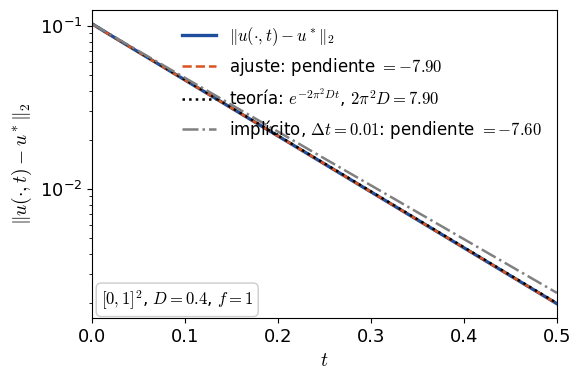

In [10]:
sel = t2 >= 0.05
pend, ordenada = np.polyfit(t2[sel], np.log(err2[sel]), 1)
lam1 = 2 * np.pi ** 2
print(f"tasa ajustada (t en [0.05, 0.5]): {-pend:.4f};  D lambda_1 = 0.8 pi^2 = {D2 * lam1:.4f};  cota del diámetro pi^2 D / d^2 = {np.pi ** 2 * D2 / 2:.4f}")
print(f"lambda_1 estimado = tasa / D = {-pend / D2:.3f}  (2 pi^2 = {lam1:.3f}; el Laplaciano discreto con h = 1/40 tiene lambda_1,h = {2 * 4 / h2 ** 2 * np.sin(np.pi * h2 / 2) ** 2:.3f})")

# el esquema implícito (Euler hacia atrás) con dt = 0.01, como la figura original del texto
dt_imp = 0.01
Mimp = spla.splu((sp.identity(m2 * m2) - dt_imp * D2 * Lap).tocsc())
v = np.zeros(m2 * m2); err_imp = [norma_L2(u_est2[1:-1, 1:-1], h2)]
for n in range(int(round(0.5 / dt_imp))):
    v = Mimp.solve(v + dt_imp * np.ones(m2 * m2)); err_imp.append(norma_L2(v.reshape(m2, m2) - u_est2[1:-1, 1:-1], h2))
t_imp = dt_imp * np.arange(len(err_imp)); err_imp = np.array(err_imp)
pend_imp = np.polyfit(t_imp, np.log(err_imp), 1)[0]
print(f"esquema implícito con dt = {dt_imp}: tasa ajustada {-pend_imp:.3f};  ln(1 + D lambda_1 dt)/dt = {np.log(1 + D2 * lam1 * dt_imp) / dt_imp:.3f}  (el 7.6 del texto)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.semilogy(t2, err2, color=COLORES["dato"], lw=2.4, label=r"$\|u(\cdot,t) - u^*\|_2$")
ax.semilogy(t2, np.exp(ordenada + pend * t2), "--", color=COLORES["modelo"], lw=1.8, label=f"ajuste: pendiente $= {pend:.2f}$")
ax.semilogy(t2, err2[0] * np.exp(-D2 * lam1 * t2), ":", color="black", lw=1.8, label=f"teoría: $e^{{-2\\pi^2 D t}}$, $2\\pi^2 D = {D2 * lam1:.2f}$")
ax.semilogy(t_imp, err_imp, "-.", color="0.5", lw=1.8, label=f"implícito, $\\Delta t = {dt_imp}$: pendiente $= {pend_imp:.2f}$")
ax.set_xlabel("$t$"); ax.set_ylabel(r"$\|u(\cdot,t) - u^*\|_2$"); ax.set_xlim(0, 0.5); ax.legend(loc="upper right", fontsize=12)
estilo.parametros(ax, "$[0,1]^2$, $D = 0.4$, $f = 1$", loc="lower left", fontsize=12)
if GUARDAR: estilo.guardar(fig, "errores-heat-log")

## Volvemos al problema: la temperatura del suelo

Los datos: `datos/suelo_horaria.csv`, el año 2023 cada hora en Aeroparque (reanálisis ERA5-Land): temperatura del aire y de cuatro **capas** de suelo, $0$–$7$, $7$–$28$, $28$–$100$ y $100$–$255$ cm. No son mediciones puntuales sino promedios sobre cada capa; cuando necesitemos una profundidad representativa usaremos el punto medio, $x = 3.5, 17.5, 64$ y $177$ cm. *Figura nueva `suelo-datos`* (la `\figpendiente` de la introducción de la Parte III): (a) una semana de enero, hora por hora, donde el ciclo diario se atenúa y se retrasa capa a capa (a $28$–$100$ cm ya no se ve); (b) el año completo en medias diarias suavizadas (media móvil de 7 días), donde el ciclo anual se atenúa mucho menos y llega con semanas de retraso a la capa más profunda.

medias anuales (°C): {'aire': 18.24, 'suelo 0–7 cm': 19.26, 'suelo 7–28 cm': 19.11, 'suelo 28–100 cm': 19.14, 'suelo 100–255 cm': 19.32}


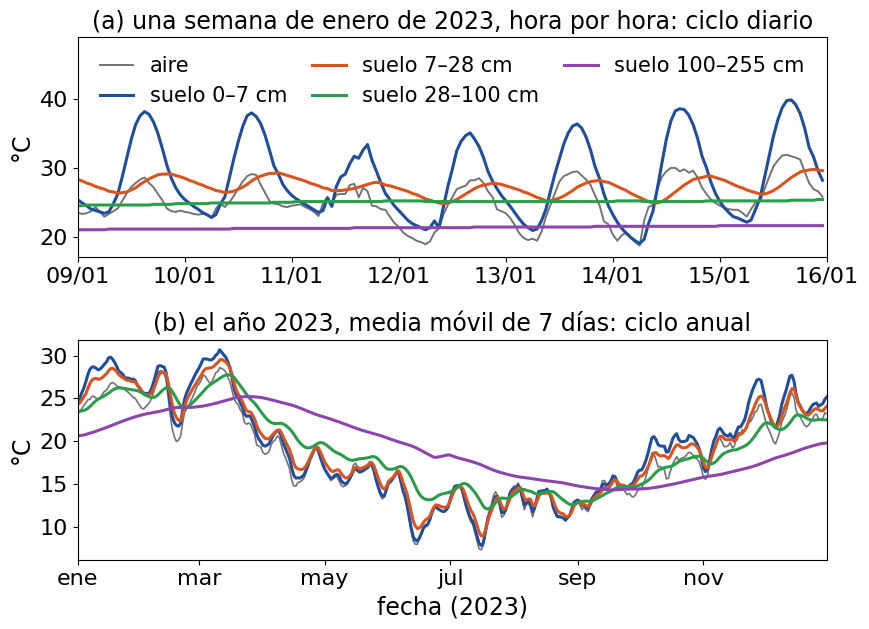

In [11]:
suelo = pd.read_csv(datos.obtener("suelo_horaria.csv"), parse_dates=["fecha_hora"])
capas = ["t_suelo_0_7", "t_suelo_7_28", "t_suelo_28_100", "t_suelo_100_255"]
etiquetas = {"t_aire": "aire", "t_suelo_0_7": "suelo 0–7 cm", "t_suelo_7_28": "suelo 7–28 cm", "t_suelo_28_100": "suelo 28–100 cm", "t_suelo_100_255": "suelo 100–255 cm"}
prof = np.array([0.035, 0.175, 0.64, 1.77])                            # puntos medios de las capas (m)
col = {"t_aire": "0.45", **{c: CICLO[i] for i, c in enumerate(capas)}}
semana = (suelo.fecha_hora >= "2023-01-09") & (suelo.fecha_hora < "2023-01-16")
diaria = suelo.set_index("fecha_hora").resample("D").mean().rolling(7, center=True, min_periods=1).mean()   # medias diarias suavizadas (media móvil de 7 días)
print("medias anuales (°C):", {etiquetas[c]: round(float(suelo[c].mean()), 2) for c in ["t_aire"] + capas})

with fuente(17):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6.6))
    for c in ["t_aire"] + capas:
        ax1.plot(suelo.fecha_hora[semana], suelo[c][semana], color=col[c], lw=2.2 if c != "t_aire" else 1.4, label=etiquetas[c])
        ax2.plot(diaria.index, diaria[c], color=col[c], lw=2.2 if c != "t_aire" else 1.2)
    ax1.set_title("(a) una semana de enero de 2023, hora por hora: ciclo diario"); ax1.set_ylabel("°C")
    ax1.xaxis.set_major_locator(mdates.DayLocator()); ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
    ax1.set_xlim(pd.Timestamp("2023-01-09"), pd.Timestamp("2023-01-16")); ax1.set_ylim(17, 49); ax1.legend(loc="upper center", ncol=3, fontsize=15, columnspacing=1.2, handlelength=1.6)
    ax2.set_title("(b) el año 2023, media móvil de 7 días: ciclo anual"); ax2.set_ylabel("°C"); ax2.set_xlabel("fecha (2023)")
    ax2.set_xticks([pd.Timestamp(f"2023-{m:02d}-01") for m in range(1, 13, 2)], ["ene", "mar", "may", "jul", "sep", "nov"])
    ax2.set_xlim(pd.Timestamp("2023-01-01"), pd.Timestamp("2023-12-31"))
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, "suelo-datos")

### La solución periódica

Para un forzado $T_s(t) = \bar T + A\cos(\omega t)$ en la superficie, la solución periódica de $u_t = Du_{xx}$ en $x > 0$ es
$$u_{per}(x,t) = \bar T + A\,e^{-x/\delta}\cos\Bigl(\omega t - \frac x\delta\Bigr),\qquad \delta = \sqrt{\frac{2D}{\omega}}:$$
la amplitud se atenúa como $e^{-x/\delta}$ y la oscilación llega con un retraso $x/(\delta\omega)$. Con el valor típico $D = 5\times10^{-7}$ m$^2$/s imprimimos $\delta$ y el retraso a profundidad $\delta$ para los ciclos diario y anual, y los comparamos con los números del texto ($12$ cm y $2.2$ m; $4$ horas y $2$ meses). *Figura nueva `suelo-periodica`* (la `\figpendiente` de la Sección "Volvemos al problema"), para el ciclo diario con $A = 5$ °C: (a) perfiles $u_{per} - \bar T$ en función de la profundidad en ocho instantes del ciclo, con la envolvente $\pm A e^{-x/\delta}$; (b) la oscilación en el tiempo a $x = 0, \delta/2, \delta, 2\delta$ y $\pi\delta$ (en contrafase con la superficie, con amplitud $e^{-\pi}A \simeq 0.2$ °C).

ciclo diario: delta = 0.117 m; retraso a profundidad delta: 1/omega = 3.8 h; contrafase a pi delta = 0.37 m; amplitud allí e^-pi = 0.043
ciclo anual : delta = 2.240 m; retraso a profundidad delta: 1/omega = 58.1 días; contrafase a pi delta = 7.04 m; amplitud allí e^-pi = 0.043
cociente delta_anual/delta_diario = 19.10 = sqrt(365) = 19.10


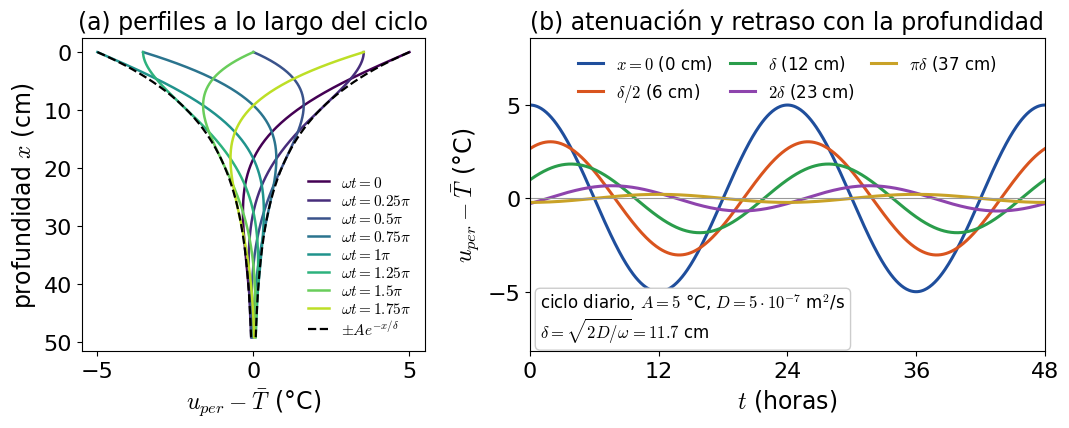

In [12]:
D_s = 5e-7                                                             # m^2/s, suelo típico
omega_d, omega_a = 2 * np.pi / 86400, 2 * np.pi / (365 * 86400)
delta = lambda D, omega: np.sqrt(2 * D / omega)
for nombre, om, unidad, esc in [("diario", omega_d, "h", 3600), ("anual", omega_a, "días", 86400)]:
    d = delta(D_s, om)
    print(f"ciclo {nombre:6s}: delta = {d:.3f} m; retraso a profundidad delta: 1/omega = {1 / om / esc:.1f} {unidad}; contrafase a pi delta = {np.pi * d:.2f} m; amplitud allí e^-pi = {np.exp(-np.pi):.3f}")
print(f"cociente delta_anual/delta_diario = {delta(D_s, omega_a) / delta(D_s, omega_d):.2f} = sqrt(365) = {np.sqrt(365):.2f}")

u_per = lambda x, t, A, D, omega: A * np.exp(-x / delta(D, omega)) * np.cos(omega * t - x / delta(D, omega))   # u_per - T_barra
A_d, d_d = 5.0, delta(D_s, omega_d)
xs = np.linspace(0, 4.2 * d_d, 400); ts = np.linspace(0, 2 * 86400, 600)
with fuente(17):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6), gridspec_kw=dict(width_ratios=[1, 1.5]))
    fases = np.arange(8) * np.pi / 4
    for ph, c in zip(fases, plt.cm.viridis(np.linspace(0, 0.9, 8))):
        ax1.plot(u_per(xs, ph / omega_d, A_d, D_s, omega_d), 100 * xs, color=c, lw=1.8, label=f"$\\omega t = {ph / np.pi:g}\\pi$" if ph else "$\\omega t = 0$")
    ax1.plot(A_d * np.exp(-xs / d_d), 100 * xs, "k--", lw=1.6); ax1.plot(-A_d * np.exp(-xs / d_d), 100 * xs, "k--", lw=1.6, label=r"$\pm A e^{-x/\delta}$")
    ax1.invert_yaxis(); ax1.set_xticks([-5, 0, 5]); ax1.set_xlabel(r"$u_{per} - \bar T$ (°C)"); ax1.set_ylabel("profundidad $x$ (cm)"); ax1.set_title("(a) perfiles a lo largo del ciclo")
    ax1.legend(loc="lower right", fontsize=11, ncol=1, handlelength=1.4, labelspacing=0.2)
    for xi, lab, c in zip([0, d_d / 2, d_d, 2 * d_d, np.pi * d_d], ["$x = 0$", r"$\delta/2$", r"$\delta$", r"$2\delta$", r"$\pi\delta$"], CICLO):
        ax2.plot(ts / 3600, u_per(xi, ts, A_d, D_s, omega_d), color=c, lw=2.2, label=f"{lab} ({100 * xi:.0f} cm)")
    ax2.axhline(0, color="0.6", lw=0.8); ax2.set_xlim(0, 48); ax2.set_xticks([0, 12, 24, 36, 48]); ax2.set_xlabel("$t$ (horas)"); ax2.set_ylabel(r"$u_{per} - \bar T$ (°C)")
    ax2.set_ylim(-8.2, 8.6); ax2.set_yticks([-5, 0, 5]); ax2.set_title("(b) atenuación y retraso con la profundidad"); ax2.legend(loc="upper center", fontsize=12, ncol=3, columnspacing=1.0, handlelength=1.5)
    estilo.parametros(ax2, f"ciclo diario, $A = {A_d:g}$ °C, $D = 5\\cdot10^{{-7}}$ m$^2$/s\n$\\delta = \\sqrt{{2D/\\omega}} = {100 * d_d:.1f}$ cm", loc="lower left", fontsize=12)
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, "suelo-periodica")

### Estimación de $D$ con los datos (pregunta 4)

A cada serie (aire y cuatro capas) le ajustamos por mínimos cuadrados $\bar T + A_1\cos(\omega_a t + \phi_1) + A_{365}\cos(\omega_d t + \phi_{365})$, con $\omega_a = 2\pi/$año y $\omega_d = 2\pi/$día (la amplitud y la fase de la Parte II). Según $u_{per}$, $\ln A(x) = \ln A(0) - x/\delta$ y $\phi(x) = \phi(0) - x/\delta$: una recta en $x$ en ambos casos, con pendiente $-1/\delta$, y de $\delta$ sale $D = \delta^2\omega/2$. Para el ciclo anual usamos las cuatro capas; para el diario sólo las dos superficiales (la tercera tiene una amplitud diaria de $0.03$ °C, por debajo de la resolución del dato), así que la "recta" pasa por dos puntos. Como cada capa es un promedio y no un punto, la profundidad $x$ es aproximada: el ajuste es indicativo.

In [13]:
t_seg = (suelo.fecha_hora - suelo.fecha_hora[0]).dt.total_seconds().values

def ajustar_ciclos(y, t):
    '''Ajusta media + A_a cos(omega_a t + phi_a) + A_d cos(omega_d t + phi_d) por mínimos cuadrados. Devuelve (media, A_a, phi_a, A_d, phi_d).'''
    M = np.c_[np.ones_like(t), np.cos(omega_a * t), np.sin(omega_a * t), np.cos(omega_d * t), np.sin(omega_d * t)]
    c = np.linalg.lstsq(M, y, rcond=None)[0]
    return c[0], np.hypot(c[1], c[2]), np.arctan2(-c[2], c[1]), np.hypot(c[3], c[4]), np.arctan2(-c[4], c[3])

ajuste = pd.DataFrame([ajustar_ciclos(suelo[c].values, t_seg) for c in ["t_aire"] + capas], index=[etiquetas[c] for c in ["t_aire"] + capas], columns=["media", "A_anual", "phi_anual", "A_diaria", "phi_diaria"])
ajuste["retraso_anual_dias"] = -(ajuste.phi_anual - ajuste.phi_anual.iloc[1]) / omega_a / 86400
ajuste["retraso_diario_h"] = -(ajuste.phi_diaria - ajuste.phi_diaria.iloc[1]) / omega_d / 3600
print(ajuste.round(3).to_string(), "\n")

def estimar_D(x, valores, omega, fase=False):
    '''Recta de ln A (o de phi) contra x: pendiente -1/delta; devuelve (delta, D, pendiente, ordenada).'''
    p, q = np.polyfit(x, valores if fase else np.log(valores), 1)
    d = -1 / p
    return d, d ** 2 * omega / 2, p, q

resultados = {}
for nombre, om, cols, ncap in [("anual", omega_a, ("A_anual", "phi_anual"), 4), ("diario", omega_d, ("A_diaria", "phi_diaria"), 2)]:
    filas = ajuste.iloc[1:1 + ncap]
    for tipo, fase in [("amplitud", False), ("fase", True)]:
        d, Dest, p, q = estimar_D(prof[:ncap], filas[cols[fase]].values, om, fase)
        resultados[(nombre, tipo)] = (d, Dest, p, q)
        print(f"ciclo {nombre:6s}, por {tipo:8s} ({ncap} capas): delta = {d:.2f} m  ->  D = {Dest:.2e} m^2/s  (típico 5e-7; delta teórica con D = 5e-7: {delta(D_s, om):.2f} m)")

                   media  A_anual  phi_anual  A_diaria  phi_diaria  retraso_anual_dias  retraso_diario_h
aire              18.242    6.916     -0.419     2.757       2.164               4.043            -0.191
suelo 0–7 cm      19.261    7.964     -0.349     4.034       2.114              -0.000            -0.000
suelo 7–28 cm     19.109    7.476     -0.437     0.934       0.849               5.081             4.833
suelo 28–100 cm   19.141    6.411     -0.680     0.028      -0.671              19.224            10.638
suelo 100–255 cm  19.317    5.080     -1.335     0.003      -2.976              57.281            19.441 

ciclo anual , por amplitud (4 capas): delta = 3.97 m  ->  D = 1.57e-06 m^2/s  (típico 5e-7; delta teórica con D = 5e-7: 2.24 m)
ciclo anual , por fase     (4 capas): delta = 1.77 m  ->  D = 3.11e-07 m^2/s  (típico 5e-7; delta teórica con D = 5e-7: 2.24 m)
ciclo diario, por amplitud (2 capas): delta = 0.10 m  ->  D = 3.33e-07 m^2/s  (típico 5e-7; delta teórica con D 

*Figura nueva `suelo-ajuste`*: arriba el ciclo anual, abajo el diario; a la izquierda $A$ contra la profundidad media de la capa en escala semilogarítmica con la recta ajustada, a la derecha el retraso de fase respecto de la capa superficial (convertido a días u horas) con su recta; en la fila del ciclo diario, los puntos huecos son la capa $28$–$100$ cm, que no se usó (su amplitud diaria de $0.03$ °C queda cerca de la extrapolación, pero su "retraso" no tiene sentido: a esa profundidad el ciclo diario ya no existe). En cada panel, el $\delta$ y el $D$ que resultan. Para el ciclo diario los dos estimadores dan $D \simeq 3$–$5\times10^{-7}$ m$^2$/s, el orden del valor típico. Para el anual, la amplitud da un $\delta$ de casi $4$ m ($D \simeq 1.5\times10^{-6}$) y la fase uno de $1.8$ m ($D \simeq 3\times10^{-7}$): los promedios sobre capas gruesas (la última mide $1.55$ m, más que $\delta$) y el propio modelo de suelo del reanálisis (que no es un semiespacio homogéneo) distorsionan las amplitudes profundas. Con mediciones puntuales a $5$–$100$ cm el ajuste diario sería el más confiable, como dice el texto.

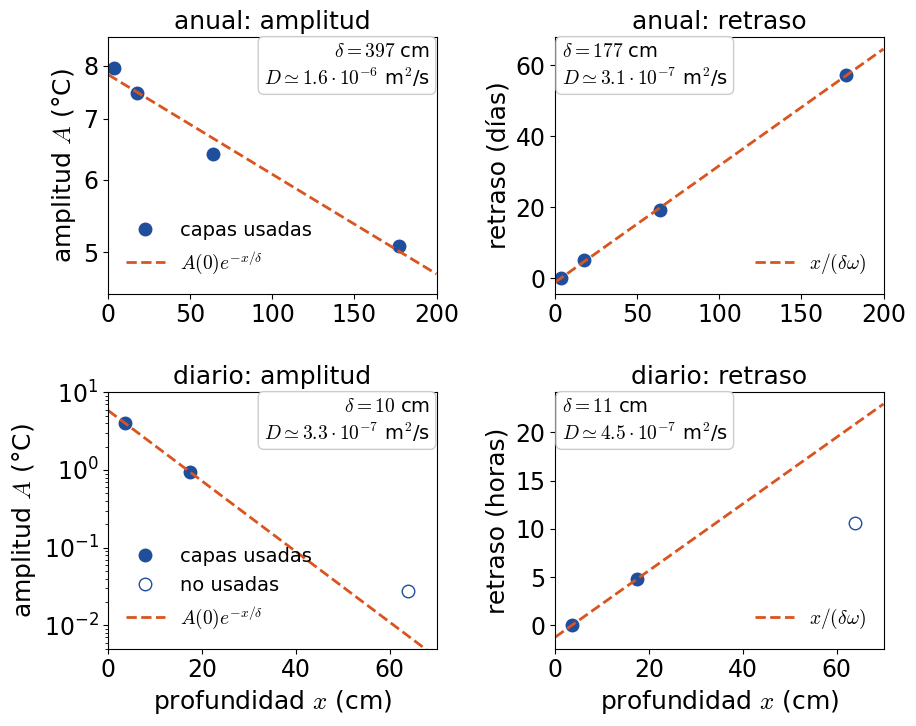

In [14]:
def cientifica(v):
    '''v como a·10^b para mathtext.'''
    b = int(np.floor(np.log10(v)))
    return f"{v / 10 ** b:.1f}\\cdot10^{{{b}}}"

with fuente(18):
    fig, axs = plt.subplots(2, 2, figsize=(9.5, 7.6))
    for fila, (nombre, om, cols, ncap, unidad, esc, xmax) in enumerate([("anual", omega_a, ("A_anual", "phi_anual"), 4, "días", 86400, 200), ("diario", omega_d, ("A_diaria", "phi_diaria"), 2, "horas", 3600, 70)]):
        filas = ajuste.iloc[1:5]
        xx = np.linspace(0, xmax / 100, 100)
        # amplitud
        ax = axs[fila, 0]
        d, Dest, p, q = resultados[(nombre, "amplitud")]
        ax.semilogy(100 * prof[:ncap], filas[cols[0]].values[:ncap], "o", color=COLORES["dato"], ms=9, label="capas usadas")
        if ncap < 4: ax.semilogy(100 * prof[ncap:], filas[cols[0]].values[ncap:], "o", mfc="white", color=COLORES["dato"], ms=9, label="no usadas")
        ax.semilogy(100 * xx, np.exp(q + p * xx), "--", color=COLORES["modelo"], lw=2, label="$A(0)e^{-x/\\delta}$")
        ax.set_ylabel("amplitud $A$ (°C)"); ax.set_title(f"{nombre}: amplitud")
        ax.legend(loc="lower left", fontsize=14)
        estilo.parametros(ax, f"$\\delta = {100 * d:.0f}$ cm\n$D \\simeq {cientifica(Dest)}$ m$^2$/s", loc="upper right", fontsize=14)
        if fila == 0: ax.set_yticks([5, 6, 7, 8], ["5", "6", "7", "8"]); ax.set_ylim(4.5, 8.6); ax.minorticks_off()
        else: ax.set_ylim(5e-3, 10)
        # fase
        ax = axs[fila, 1]
        d, Dest, p, q = resultados[(nombre, "fase")]
        ret = -(filas[cols[1]].values - filas[cols[1]].values[0]) / om / esc
        ax.plot(100 * prof[:ncap], ret[:ncap], "o", color=COLORES["dato"], ms=9)
        if ncap < 4: ax.plot(100 * prof[ncap:], ret[ncap:], "o", mfc="white", color=COLORES["dato"], ms=9)
        ax.plot(100 * xx, -(q + p * xx - filas[cols[1]].values[0]) / om / esc, "--", color=COLORES["modelo"], lw=2, label="$x/(\\delta\\omega)$")
        ax.set_ylabel(f"retraso ({unidad})"); ax.set_title(f"{nombre}: retraso"); ax.legend(loc="lower right", fontsize=14)
        estilo.parametros(ax, f"$\\delta = {100 * d:.0f}$ cm\n$D \\simeq {cientifica(Dest)}$ m$^2$/s", loc="upper left", fontsize=14)
        for ax in axs[fila]: ax.set_xlim(0, xmax)
    for ax in axs[1]: ax.set_xlabel("profundidad $x$ (cm)")
    fig.tight_layout(h_pad=1.5)
    if GUARDAR: estilo.guardar(fig, "suelo-ajuste")

### ¿A qué profundidad enterrar una cañería? (pregunta 5)

Con $u_{per}$ para el ciclo anual, la temperatura mínima del año a profundidad $x$ es $\bar T - A e^{-x/\delta_a}$ (el mínimo del coseno), y la cañería no se congela si eso es positivo: $x > \delta_a\ln(A/\bar T)$, que sólo impone algo si $A > \bar T$. *Figura nueva `suelo-caneria`* (opcional, al final de la sección): con los valores ajustados de Buenos Aires ($\bar T \simeq 19$ °C, $A \simeq 8$ °C) la curva nunca baja de $0$: no se congela ni en la superficie (la mínima anual del modelo periódico es de unos $11$ °C). Para un clima frío hipotético con $\bar T = 5$ °C y $A = 15$ °C, con el mismo $D = 5\times10^{-7}$, hay que bajar hasta $x = \delta_a\ln 3 \simeq 2.5$ m. Como la amplitud real de la superficie incluye días extremos que el coseno anual no ve, en la práctica se agrega un margen.

Buenos Aires (ajustado) : T_barra =  19.3 °C, A =   8.0 °C, mínima en superficie  11.3 °C; profundidad sin congelamiento: ninguna (no se congela)
clima frío hipotético   : T_barra =   5.0 °C, A =  15.0 °C, mínima en superficie -10.0 °C; profundidad sin congelamiento: 2.46 m


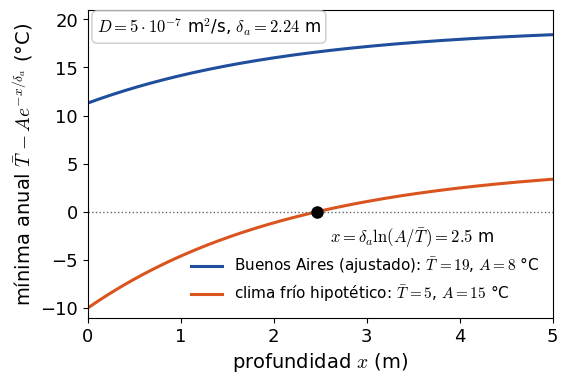

In [15]:
d_a = delta(D_s, omega_a)
Tb_BA, A_BA = ajuste.loc["suelo 0–7 cm", "media"], ajuste.loc["suelo 0–7 cm", "A_anual"]
xs_a = np.linspace(0, 5, 300)
climas = [("Buenos Aires (ajustado)", Tb_BA, A_BA, COLORES["dato"]), ("clima frío hipotético", 5.0, 15.0, COLORES["modelo"])]
fig, ax = plt.subplots(figsize=(6, 4))
for nombre, Tb, A, c in climas:
    ax.plot(xs_a, Tb - A * np.exp(-xs_a / d_a), color=c, lw=2.2, label=f"{nombre}: $\\bar T = {Tb:.0f}$, $A = {A:.0f}$ °C")
    x_cong = d_a * np.log(A / Tb) if A > Tb else None
    print(f"{nombre:24s}: T_barra = {Tb:5.1f} °C, A = {A:5.1f} °C, mínima en superficie {Tb - A:5.1f} °C; profundidad sin congelamiento: {'ninguna (no se congela)' if x_cong is None else f'{x_cong:.2f} m'}")
    if x_cong is not None:
        ax.plot(x_cong, 0, "o", color="black", ms=8, zorder=5); ax.annotate(f"$x = \\delta_a\\ln(A/\\bar T) = {x_cong:.1f}$ m", (x_cong, 0), (10, -22), textcoords="offset points", fontsize=12)
ax.axhline(0, color="0.4", lw=1, ls=":")
ax.set_xlabel("profundidad $x$ (m)"); ax.set_ylabel(r"mínima anual $\bar T - A e^{-x/\delta_a}$ (°C)"); ax.set_xlim(0, 5); ax.set_ylim(-11, 21); ax.legend(loc="lower right", fontsize=11)
estilo.parametros(ax, f"$D = 5\\cdot10^{{-7}}$ m$^2$/s, $\\delta_a = {d_a:.2f}$ m", loc="upper left", fontsize=12)
if GUARDAR: estilo.guardar(fig, "suelo-caneria")

## Para experimentar

1. En el paseo al azar, hacé los saltos asimétricos (derecha con probabilidad $\alpha = 0.6$): ¿cómo se mueve el histograma con $n$? Comprobá que la media crece como $(\alpha - \beta)\,n\,\Delta x$ y la varianza sigue siendo $\approx n\,\Delta x^2$ (es la ecuación de Fokker–Planck con deriva $v$ de la Sección 18.2). Después reemplazá el histograma por la solución de $u_t = -vu_x + Du_{xx}$ con `calor_explicito` sobre una grilla grande y compará.
2. En la barra, cambiá la condición del extremo derecho por una de Neumann (aislado: $u_x(L,t) = 0$, que en el esquema se impone copiando el penúltimo nodo) y el dato inicial por un pulso en el centro. Verificá que ahora se conserva $\int_0^L u\,dx$ (calculala en cada paso) y que el estado estacionario es la constante $u_0$: ¿cuál es la tasa de convergencia, y con qué $\lambda_1$ se corresponde?
3. En el cuadrado, repetí el ajuste de la tasa con $D = 0.1$ y con el dominio $[0,2]\times[0,1]$ (cambiá `xg2` y el `kron`): la teoría dice $\lambda_1 = \pi^2(1/a^2 + 1/b^2)$ para el rectángulo $[0,a]\times[0,b]$. Probá también un dato inicial $g = \sin(2\pi x)\sin(\pi y)$ (con $f = 0$): ¿qué tasa ves al principio y cuál al final?
4. Con los datos del suelo, ajustá $D$ usando sólo el verano (enero y febrero), donde el ciclo diario es más fuerte, y compará con el ajuste de todo el año. Superponé la predicción $u_{per}$ (con el $\bar T$, $A$ y $\phi$ de la capa superficial y tu $D$) a la serie de la capa $7$–$28$ cm durante una semana: ¿cuánto del error es atribuible a que la capa es un promedio entre $7$ y $28$ cm? (Promediá $u_{per}$ en $x$ sobre la capa y volvé a comparar.)